# Import Libraries 

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


# Load Dataset

In [3]:
#read the csv and perform all the numpy and pandas functions
df = pd.read_csv("AI_Impact_on_Jobs_2030.csv", delimiter=',')

print("df: ", df)
print("df.head():  ", df.head())
print("df.info() : ", df.info())
print("df.describe(): ", df.describe())
print("df.shape:  ", df.shape)
print("df.columns: ", df.columns)
print("Null values:\n", df.isnull().sum())
print("Duplicates:", df.duplicated().sum())

df:                  Job_Title  Average_Salary  Years_Experience Education_Level  \
0          Security Guard           45795                28        Master's   
1      Research Scientist          133355                20             PhD   
2     Construction Worker          146216                 2     High School   
3       Software Engineer          136530                13             PhD   
4       Financial Analyst           70397                22     High School   
...                   ...             ...               ...             ...   
2995               Doctor          111319                 6      Bachelor's   
2996        UX Researcher           44363                29             PhD   
2997       Data Scientist           61325                23        Master's   
2998     Graphic Designer          110296                 7             PhD   
2999     Graphic Designer          123909                25             PhD   

      AI_Exposure_Index  Tech_Growth_Factor  A

# Numpy Operations

In [4]:
automation_prob = np.array(df['Automation_Probability_2030'].dropna())

print("Automation Probability 2030 Mean         : ", np.mean(automation_prob))
print("Automation Probability 2030 Average      : ", np.average(automation_prob))
print("Automation Probability 2030 Std          : ", np.std(automation_prob))
print("Automation Probability 2030 Median       : ", np.median(automation_prob))
print("Automation Probability 2030 Percentile 25: ", np.percentile(automation_prob, 25))
print("Automation Probability 2030 Percentile 75: ", np.percentile(automation_prob, 75))
print("Automation Probability 2030 Percentile 3 : ", np.percentile(automation_prob, 3))
print("Automation Probability 2030 Min          : ", np.min(automation_prob))
print("Automation Probability 2030 Max          : ", np.max(automation_prob))

Automation Probability 2030 Mean         :  0.5015033333333333
Automation Probability 2030 Average      :  0.5015033333333333
Automation Probability 2030 Std          :  0.24783994833135536
Automation Probability 2030 Median       :  0.5
Automation Probability 2030 Percentile 25:  0.31
Automation Probability 2030 Percentile 75:  0.7
Automation Probability 2030 Percentile 3 :  0.08
Automation Probability 2030 Min          :  0.05
Automation Probability 2030 Max          :  0.95


# Seaborn Graphs

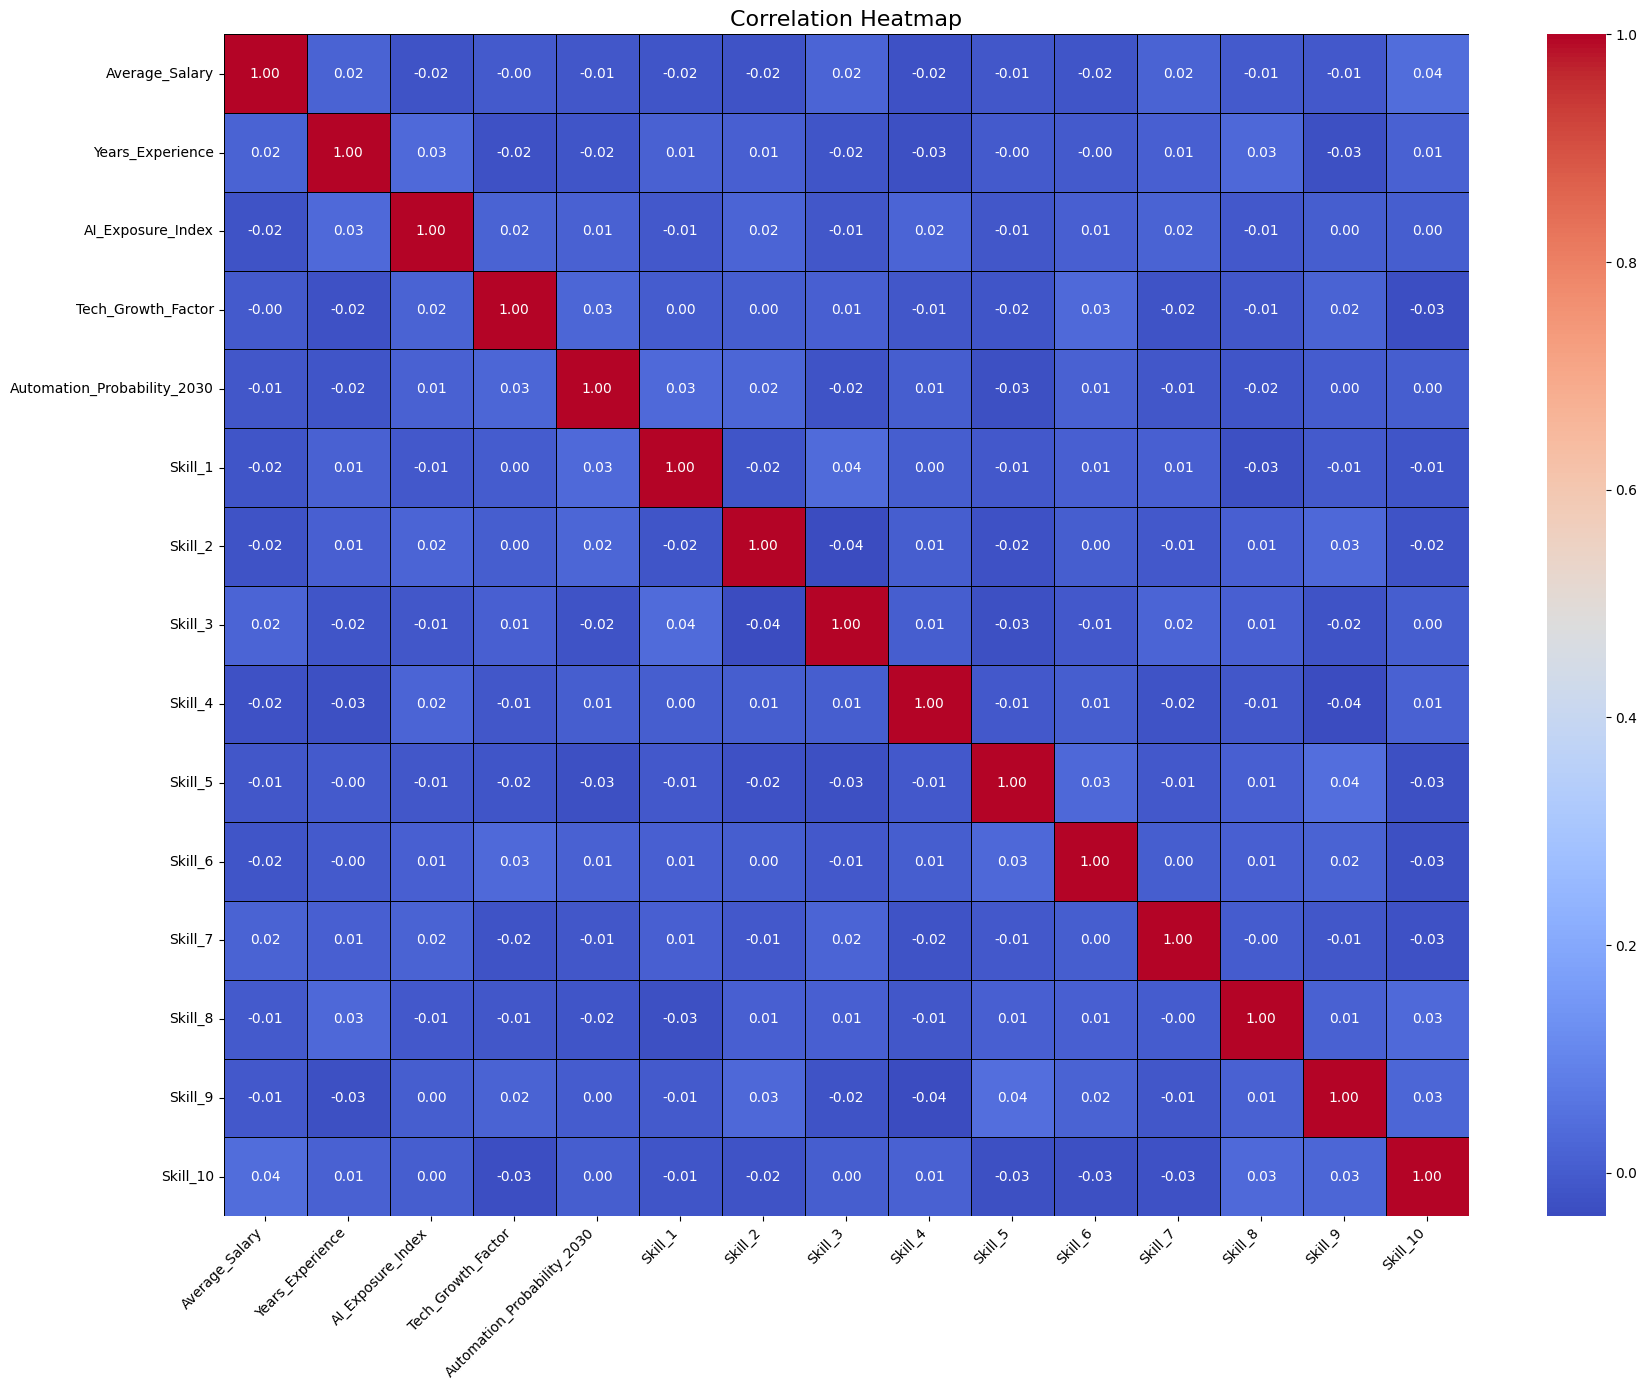

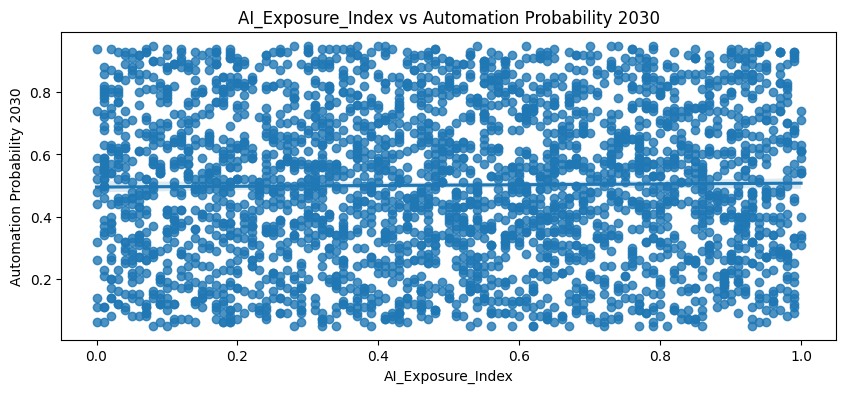

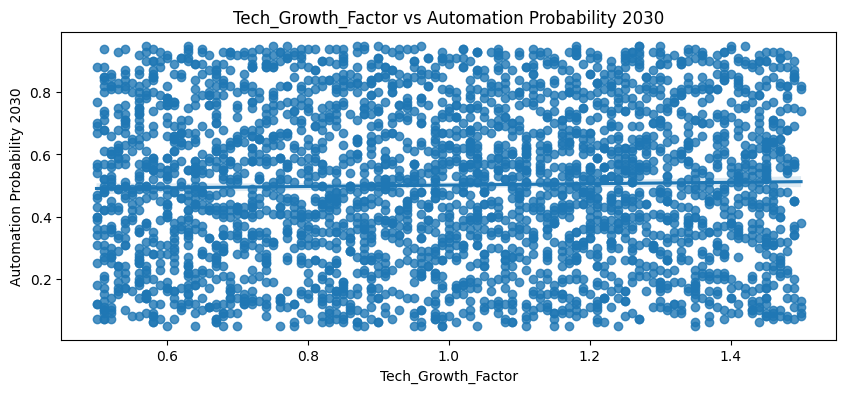

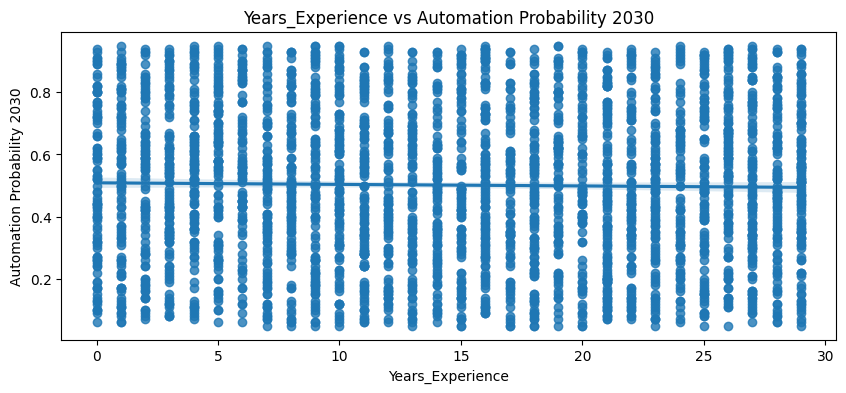

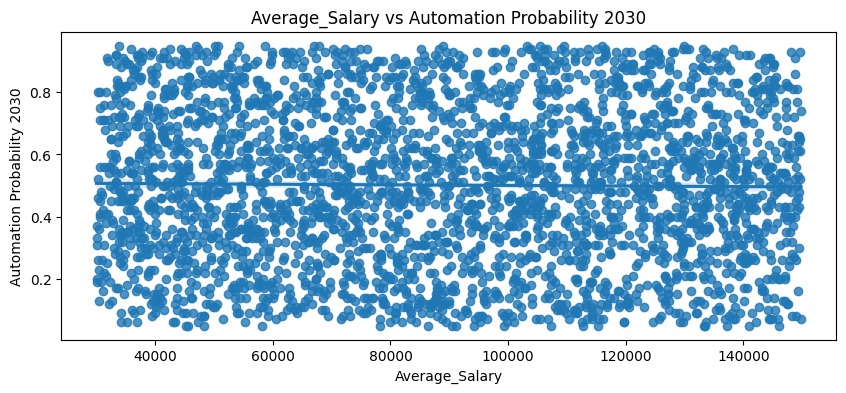

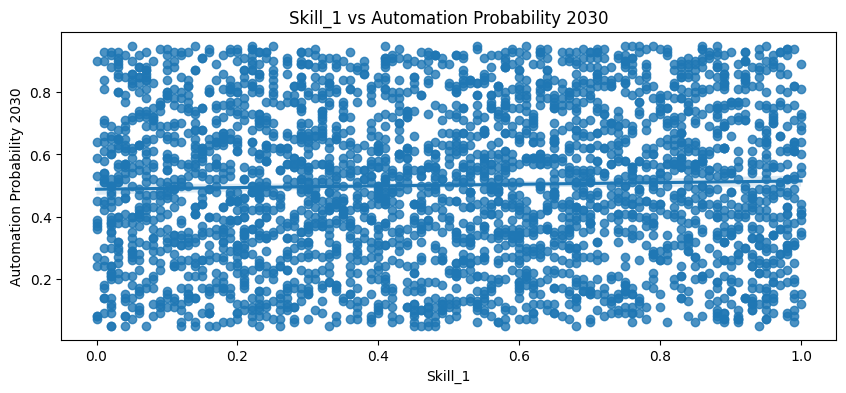

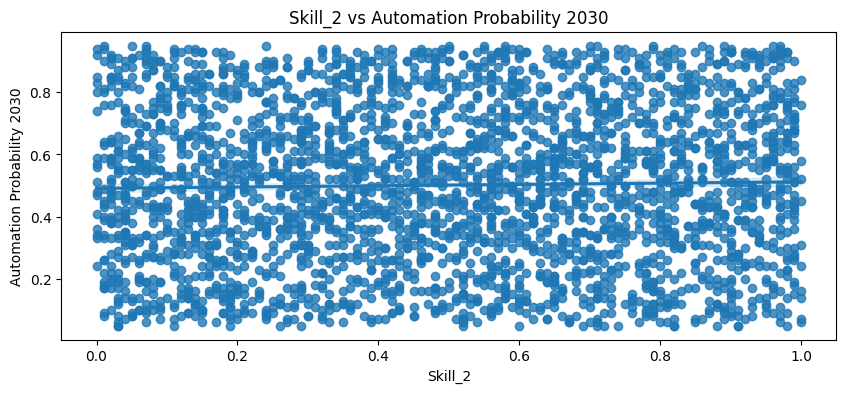

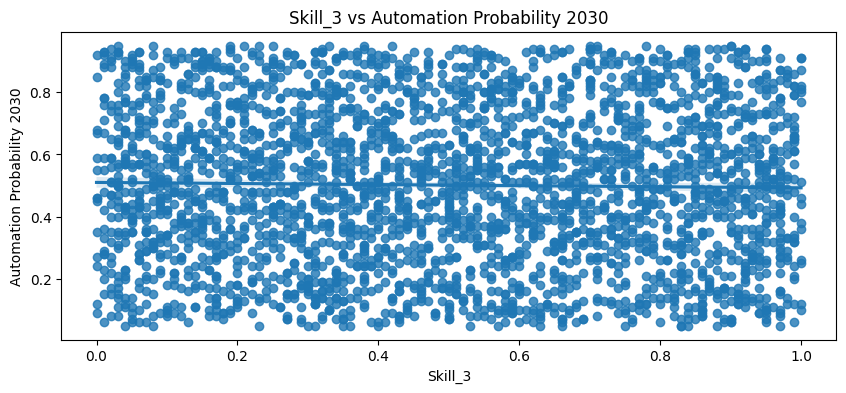

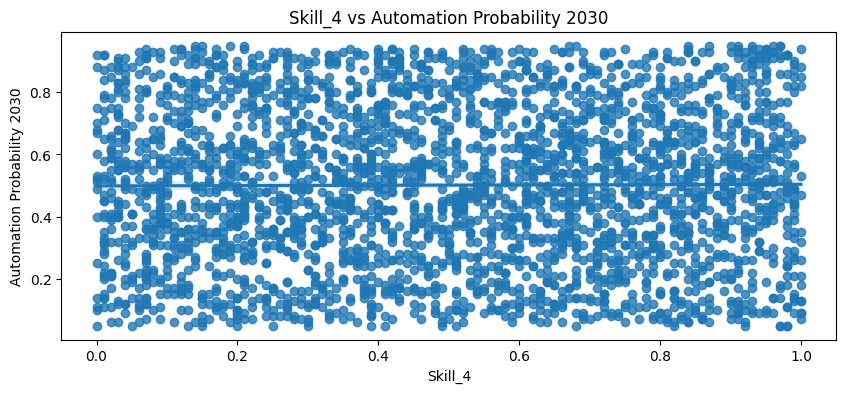

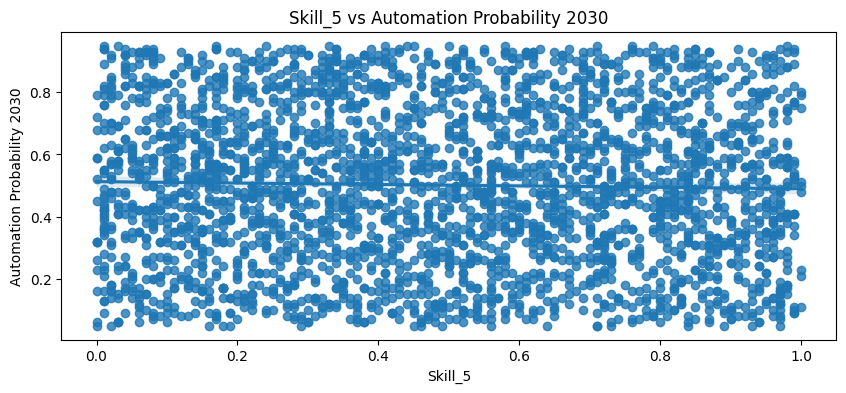

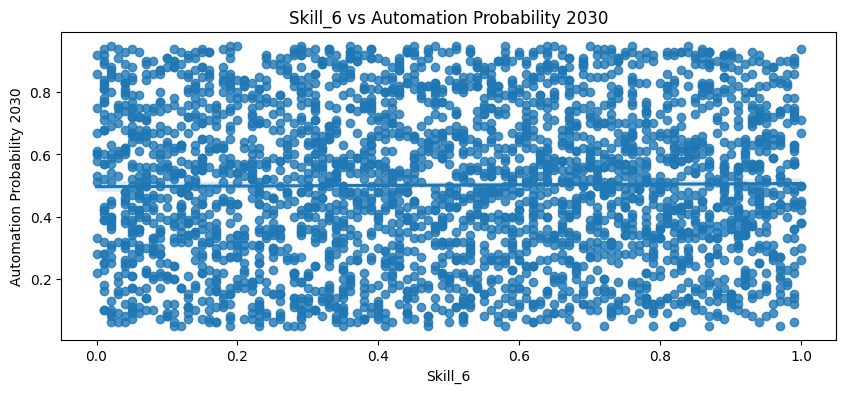

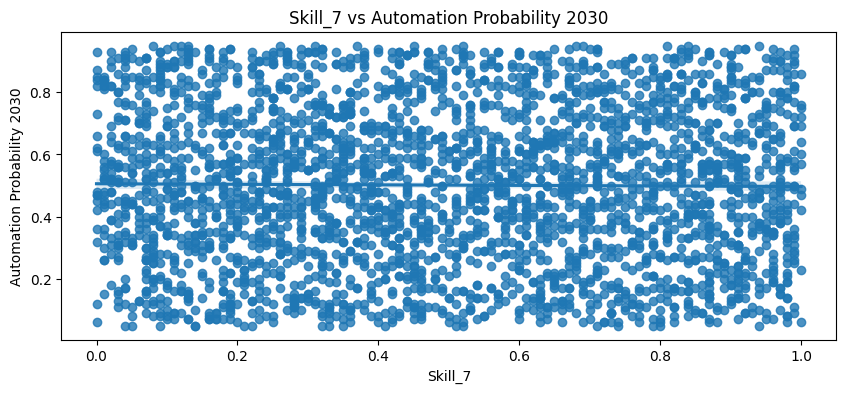

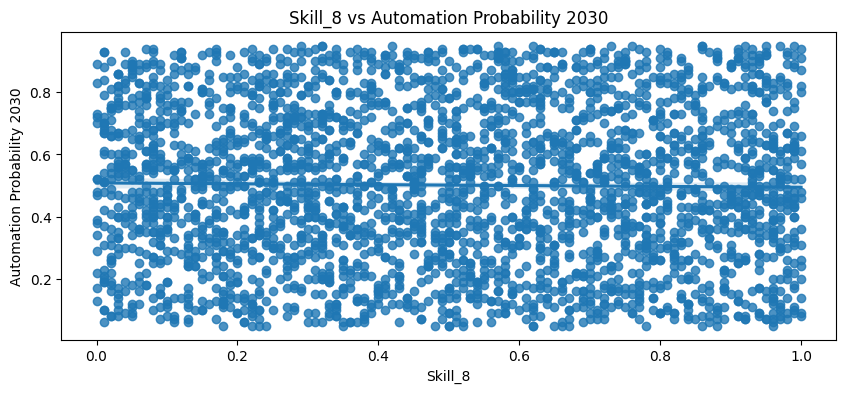

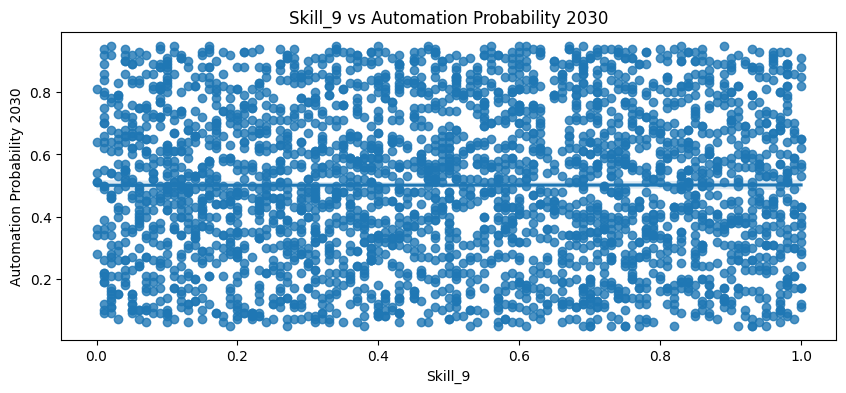

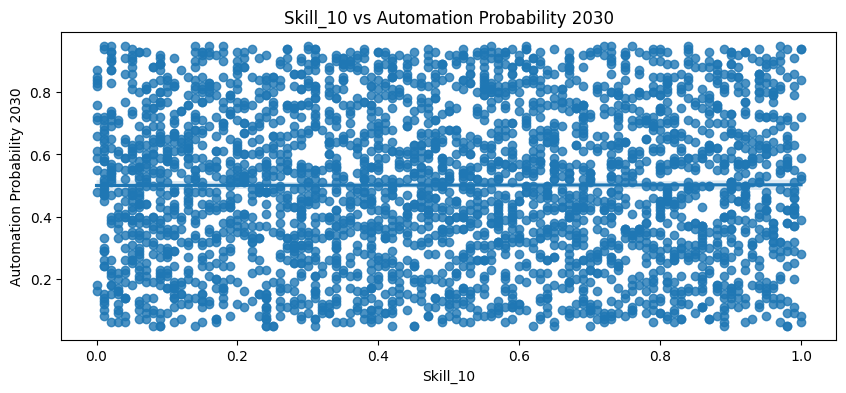

In [5]:
#heatmap  
plt.figure(figsize=(18, 14)) 
sns.heatmap(df.corr(numeric_only=True), 
            annot=True, 
            fmt=".2f",     
            cmap='coolwarm',  
            annot_kws={"size": 10},
            linewidths=0.5,   
            linecolor='black')   
plt.title("Correlation Heatmap", fontsize=16)   
plt.xticks(fontsize=10, rotation=45, ha='right')  
plt.yticks(fontsize=10, rotation=0)  

plt.tight_layout()  
plt.show()

variables = ['AI_Exposure_Index', 'Tech_Growth_Factor',
             'Years_Experience', 'Average_Salary',
             'Skill_1', 'Skill_2', 'Skill_3', 'Skill_4',
             'Skill_5', 'Skill_6', 'Skill_7', 'Skill_8',
             'Skill_9', 'Skill_10']

for var in variables:
    plt.figure(figsize=(10, 4))
    sns.regplot(x=var, y='Automation_Probability_2030', data=df)
    plt.title(f'{var} vs Automation Probability 2030')
    plt.xlabel(var)
    plt.ylabel('Automation Probability 2030')
    plt.show()


    # By drawing regplot i have noticed that there is no such relation of any numerical column with ai automation probability 2030 because the line is not continous 



# Encoding all the categorical Columns

In [7]:

from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder

# 1. Job_Title — OneHotEncoder
ohe = OneHotEncoder(sparse_output=False, drop='first')
ohe_array = ohe.fit_transform(df[['Job_Title']])
ohe_df = pd.DataFrame(ohe_array,
                       columns=ohe.get_feature_names_out(['Job_Title']))
df = df.drop(columns=['Job_Title'])
df = pd.concat([df.reset_index(drop=True),
                ohe_df.reset_index(drop=True)], axis=1)
print("After Job_Title encoding:", df.shape)

# 2. Education_Level — OrdinalEncoder
categories_order = [['High School', "Bachelor's", "Master's", 'PhD']]
oe = OrdinalEncoder(categories=categories_order)
df['Education_Level_ord'] = oe.fit_transform(df[['Education_Level']])
df = df.drop(columns=['Education_Level'])
print("After Education_Level encoding:", df.shape)

# 3. Risk_Category — LabelEncoder
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Risk_Category_encoded'] = le.fit_transform(df['Risk_Category'])
df = df.drop(columns=['Risk_Category'])
print("Mapping:", dict(zip(le.classes_, le.transform(le.classes_))))
print("After Risk_Category encoding:", df.shape)

After Job_Title encoding: (3000, 36)
After Education_Level encoding: (3000, 36)
Mapping: {'High': np.int64(0), 'Low': np.int64(1), 'Medium': np.int64(2)}
After Risk_Category encoding: (3000, 36)


# Feature Selection all 3 models applied

In [8]:

X = df.drop(columns=['Automation_Probability_2030'])
y = df['Automation_Probability_2030']  


from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error,mean_absolute_percentage_error,median_absolute_error,explained_variance_score,max_error

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

feature_names = X.columns.tolist()

# LINEAR REGRESSION
regressor = LinearRegression()
regressor.fit(X_train, y_train)

print("=" * 50)
print("V3 — LINEAR REGRESSION")
print("=" * 50)
print("Intercept:", regressor.intercept_)

coef_df = pd.DataFrame(data=regressor.coef_,
                        index=feature_names,
                        columns=['Coefficient value'])
print(coef_df)

y_pred_lr = regressor.predict(X_test)
results = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred_lr})
print("Actual vs Predicted:\n", results)

mae  = mean_absolute_error(y_test, y_pred_lr)
mse  = mean_squared_error(y_test, y_pred_lr)
rmse = np.sqrt(mse)
actual_minus_predicted   = sum((y_test - y_pred_lr)**2)
actual_minus_actual_mean = sum((y_test - y_test.mean())**2)
r2 = 1 - actual_minus_predicted / actual_minus_actual_mean


print(f'MAE  : {mae:.2f}')
print(f'MSE  : {mse:.2f}')
print(f'RMSE : {rmse:.2f}')
print(f'R²   : {r2:.4f}')


# Linear Regression Results:
# R² = 86.34% — model explains 86% variance in Automation Probability
# Job_Title (OHE encoded) is the strongest predictor
# Security Guard, Truck Driver, Construction Worker have highest
# automation probability — matches real world expectations
# Doctor, Teacher, Nurse have lowest automation risk
# MAE = 0.08 means predictions are off by only 0.08 on average
# MSE = 0.01, RMSE = 0.09 — very low error rate

# RIDGE REGRESSION
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

print("\n" + "=" * 50)
print("V3 — RIDGE REGRESSION")
print("=" * 50)
print("Intercept:", ridge.intercept_)

ridge_coef_df = pd.DataFrame(data=ridge.coef_,
                              index=feature_names,
                              columns=['Coefficient value'])
print(ridge_coef_df)

y_pred_ridge = ridge.predict(X_test)
results_ridge = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred_ridge})
print("Actual vs Predicted:\n", results_ridge)

mae  = mean_absolute_error(y_test, y_pred_ridge)
mse  = mean_squared_error(y_test, y_pred_ridge)
rmse = np.sqrt(mse)
actual_minus_predicted   = sum((y_test - y_pred_ridge)**2)
actual_minus_actual_mean = sum((y_test - y_test.mean())**2)
r2 = 1 - actual_minus_predicted / actual_minus_actual_mean

print(f'MAE  : {mae:.2f}')
print(f'MSE  : {mse:.2f}')
print(f'RMSE : {rmse:.2f}')
print(f'R²   : {r2:.4f}')


# Ridge Regression Results:
# R² = 86.35% — slightly better than Linear Regression
# Ridge uses alpha=1.0 — penalizes large coefficients
# All coefficients slightly smaller than Linear Regression
# Ridge did NOT zero out any feature — kept all features
# but reduced their impact to avoid overfitting
# Job_Title features still dominate the predictions
# MAE, MSE, RMSE same as Linear — Ridge did not change predictions much
# Best use: when multicollinearity is present between features


# LASSO REGRESSION
lasso = Lasso(alpha=0.001, max_iter=10000)
lasso.fit(X_train, y_train)

print("\n" + "=" * 50)
print("V3 — LASSO REGRESSION")
print("=" * 50)
print("Intercept:", lasso.intercept_)

lasso_coef_df = pd.DataFrame(data=lasso.coef_,
                              index=feature_names,
                              columns=['Coefficient value'])
print(lasso_coef_df)

y_pred_lasso = lasso.predict(X_test)
results_lasso = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred_lasso})
print("Actual vs Predicted:\n", results_lasso)

mae  = mean_absolute_error(y_test, y_pred_lasso)
mse  = mean_squared_error(y_test, y_pred_lasso)
rmse = np.sqrt(mse)
actual_minus_predicted   = sum((y_test - y_pred_lasso)**2)
actual_minus_actual_mean = sum((y_test - y_test.mean())**2)
r2 = 1 - actual_minus_predicted / actual_minus_actual_mean
mape = mean_absolute_percentage_error(y_test, y_pred_lasso)
med_ae = median_absolute_error(y_test, y_pred_lasso)
evs  = explained_variance_score(y_test, y_pred_lasso)
max_err = max_error(y_test, y_pred_lasso)

print(f'MAE  : {mae:.2f}')
print(f'MSE  : {mse:.2f}')
print(f'RMSE : {rmse:.2f}')
print(f'R²   : {r2:.4f}')
print(f'MAPE                      : {mape*100:.2f}%')
print(f'Median Absolute Error     : {med_ae:.4f}')
print(f'Explained Variance Score  : {evs:.4f}')
print(f'Max Error                 : {max_err:.4f}')

# Lasso Regression Results:
# R² = 86.39% — Best among all three models
# Lasso uses alpha=0.001 — automatic feature selection
# Features zeroed out by Lasso (not important):
#   Average_Salary     → 0.000 (removed)
#   AI_Exposure_Index  → 0.000 (removed)
#   Risk_Category_enc  → 0.000 (removed)
#   Skill_1,3,5,6,7,8,9 → 0.000 (removed)
# Features kept by Lasso (important):
#   All Job_Title columns — most important predictors
#   Years_Experience, Tech_Growth_Factor, Skill_2, Skill_4, Skill_10
# Lasso gave cleanest model with highest R² = 86.39%


# V3 CONCLUSION
# Target: Automation_Probability_2030 (continuous — regression)
# Features: All columns after encoding (36 total)
#   - Job_Title    → OneHotEncoding (19 dummy columns)
#   - Education    → OrdinalEncoding (0,1,2,3)
#   - Risk_Category → LabelEncoding (0,1,2)
#   - Numeric      → Skills, Salary, Experience, AI_Index
#
# Best Model   : Lasso (R² = 86.39%)
# Best Metrics : MAE=0.08, MSE=0.01, RMSE=0.09
#
# Key Finding  : Job_Title is the most important predictor
#                Manual/routine jobs = high automation risk
#                Knowledge/creative jobs = low automation risk

V3 — LINEAR REGRESSION
Intercept: 0.5007583333333333
                               Coefficient value
Average_Salary                          0.001190
Years_Experience                       -0.001978
AI_Exposure_Index                      -0.000082
Tech_Growth_Factor                      0.001052
Skill_1                                -0.000230
Skill_2                                 0.003202
Skill_3                                 0.001059
Skill_4                                 0.001764
Skill_5                                -0.001007
Skill_6                                 0.000010
Skill_7                                -0.000487
Skill_8                                 0.000200
Skill_9                                 0.000951
Skill_10                               -0.001654
Job_Title_Chef                          0.075975
Job_Title_Construction Worker           0.139421
Job_Title_Customer Support              0.130530
Job_Title_Data Scientist                0.083587
Job_Title_Doctor

#  Ensemble Learning (Regression Models)

In [10]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, BaggingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

rf_mae  = mean_absolute_error(y_test, rf_pred)
rf_mse  = mean_squared_error(y_test, rf_pred)
rf_rmse = np.sqrt(rf_mse)
rf_r2   = r2_score(y_test, rf_pred)

print("Random Forest Performance")
print("-" * 30)
print(f"MAE  : {rf_mae:.4f}")
print(f"MSE  : {rf_mse:.4f}")
print(f"RMSE : {rf_rmse:.4f}")
print(f"R²   : {rf_r2:.4f}")

# Gradient Boosting
gb_model = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb_model.fit(X_train, y_train)
gb_pred = gb_model.predict(X_test)

gb_mae  = mean_absolute_error(y_test, gb_pred)
gb_mse  = mean_squared_error(y_test, gb_pred)
gb_rmse = np.sqrt(gb_mse)
gb_r2   = r2_score(y_test, gb_pred)

print("\nGradient Boosting Performance")
print("-" * 30)
print(f"MAE  : {gb_mae:.4f}")
print(f"MSE  : {gb_mse:.4f}")
print(f"RMSE : {gb_rmse:.4f}")
print(f"R²   : {gb_r2:.4f}")

# Bagging Regressor
bag_model = BaggingRegressor(n_estimators=100, random_state=42)
bag_model.fit(X_train, y_train)
bag_pred = bag_model.predict(X_test)

bag_mae  = mean_absolute_error(y_test, bag_pred)
bag_mse  = mean_squared_error(y_test, bag_pred)
bag_rmse = np.sqrt(bag_mse)
bag_r2   = r2_score(y_test, bag_pred)

print("\nBagging Regressor Performance")
print("-" * 30)
print(f"MAE  : {bag_mae:.4f}")
print(f"MSE  : {bag_mse:.4f}")
print(f"RMSE : {bag_rmse:.4f}")
print(f"R²   : {bag_r2:.4f}")

Random Forest Performance
------------------------------
MAE  : 0.0787
MSE  : 0.0088
RMSE : 0.0938
R²   : 0.8623

Gradient Boosting Performance
------------------------------
MAE  : 0.0784
MSE  : 0.0087
RMSE : 0.0935
R²   : 0.8630

Bagging Regressor Performance
------------------------------
MAE  : 0.0787
MSE  : 0.0088
RMSE : 0.0938
R²   : 0.8621


# Findings

In [9]:
# Three ensemble models were applied on V3 features
# to predict Automation Probability 2030.

# Gradient Boosting → Best model (R²: 86.30%, MAE: 0.0784)
# Random Forest     → Second best (R²: 86.23%, MAE: 0.0787)
# Bagging Regressor → Third (R²: 86.21%, MAE: 0.0787)

# Lasso (86.39%) slightly outperformed all ensemble models
# because dataset is synthetically generated and
# Job Title encoding drives most of the predictions.


# Model Comparison Plot

C:\Users\Hp\AppData\Local\Temp\ipykernel_4240\827103745.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=r2_scores, palette='coolwarm', ax=axes[0])
C:\Users\Hp\AppData\Local\Temp\ipykernel_4240\827103745.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=mae_scores, palette='coolwarm', ax=axes[1])


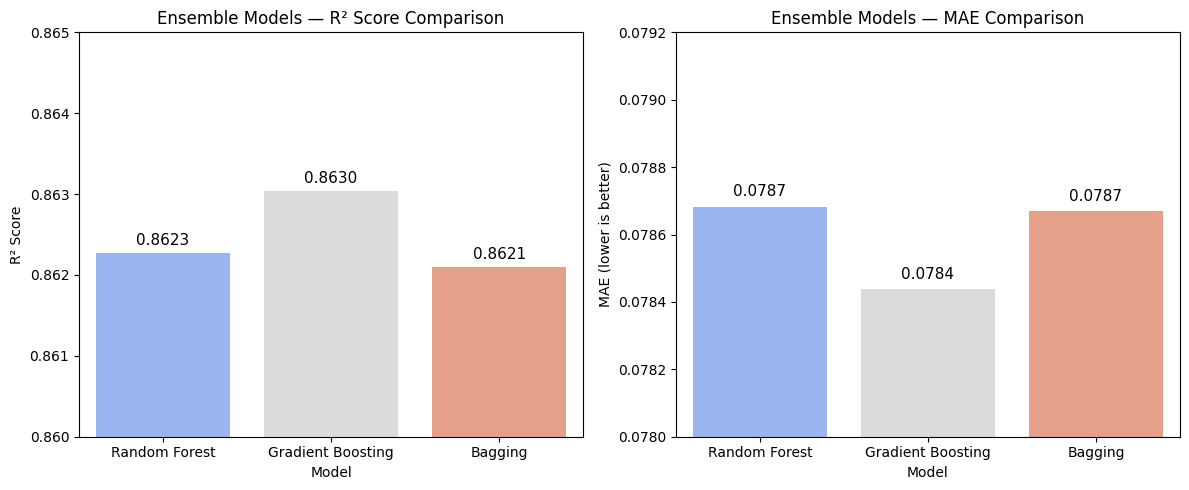

In [12]:

# ENSEMBLE LEARNING — MODEL COMPARISON PLOT

models = ['Random Forest', 'Gradient Boosting', 'Bagging']
r2_scores  = [rf_r2, gb_r2, bag_r2]
mae_scores = [rf_mae, gb_mae, bag_mae]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# R² Score Comparison
sns.barplot(x=models, y=r2_scores, palette='coolwarm', ax=axes[0])
axes[0].set_title("Ensemble Models — R² Score Comparison")
axes[0].set_xlabel("Model")
axes[0].set_ylabel("R² Score")
axes[0].set_ylim(0.860, 0.865)
for i, v in enumerate(r2_scores):
    axes[0].text(i, v + 0.0001, f'{v:.4f}', ha='center', fontsize=11)

# MAE Score Comparison
sns.barplot(x=models, y=mae_scores, palette='coolwarm', ax=axes[1])
axes[1].set_title("Ensemble Models — MAE Comparison")
axes[1].set_xlabel("Model")
axes[1].set_ylabel("MAE (lower is better)")
axes[1].set_ylim(0.078, 0.0792)
for i, v in enumerate(mae_scores):
    axes[1].text(i, v + 0.00003, f'{v:.4f}', ha='center', fontsize=11)

plt.tight_layout()
plt.show()